In [20]:
# 1b

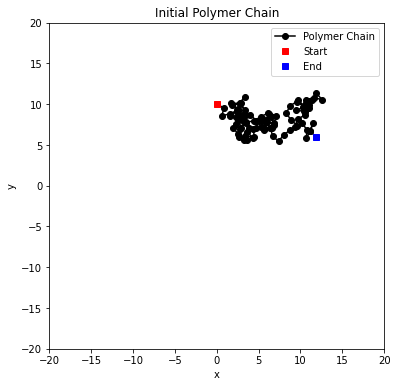

In [21]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# Variables
N = 100  # Number of residues
world = 20  # Sets up a world that is a 2*world grid
starting_position = [0, 10]  # Starting position of the first residue

# Initialize residues
positionsX = [starting_position[0]]
positionsY = [starting_position[1]]

# Generate the initial chain
for m in range(N - 1):
    angle = np.random.random() * np.pi * 2  # Random angle between 0 and 2*pi
    x = positionsX[m] + np.cos(angle)  # Compute next x position
    y = positionsY[m] + np.sin(angle)  # Compute next y position
    positionsX.append(x)
    positionsY.append(y)

# Plot the initial chain
fig, ax = plt.subplots(figsize=(6, 6))
ax.set(xlabel='x', ylabel='y', xlim=[-world, world], ylim=[-world, world])
ax.plot(positionsX, positionsY, '-o', color='k', label='Polymer Chain')
ax.plot(positionsX[0], positionsY[0], 'rs', label='Start')
ax.plot(positionsX[-1], positionsY[-1], 'bs', label='End')
ax.legend()
plt.title("Initial Polymer Chain")
plt.show()


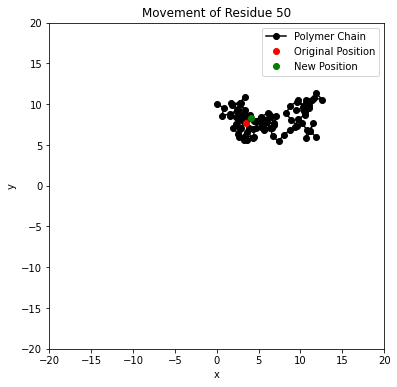

In [22]:
def move_residue(i, positionsX, positionsY, world):
    """
    Move a single residue in the chain while respecting chain constraints.
    - i: Index of the residue to move.
    - positionsX, positionsY: Current x and y positions of residues.
    - world: Boundary for movement.
    """
    if i == 0:  # First residue has only one neighbor
        new_x = positionsX[i] + np.random.uniform(-1, 1)
        new_y = positionsY[i] + np.random.uniform(-1, 1)
        # Constrain to world boundaries
        if -world <= new_x <= world and -world <= new_y <= world:
            positionsX[i], positionsY[i] = new_x, new_y

    elif i == len(positionsX) - 1:  # Last residue has only one neighbor
        new_x = positionsX[i] + np.random.uniform(-1, 1)
        new_y = positionsY[i] + np.random.uniform(-1, 1)
        # Constrain to world boundaries
        if -world <= new_x <= world and -world <= new_y <= world:
            positionsX[i], positionsY[i] = new_x, new_y

    else:  # Middle residues must maintain distances to neighbors
        # Compute midpoint of adjacent residues
        mid_x = (positionsX[i - 1] + positionsX[i + 1]) / 2
        mid_y = (positionsY[i - 1] + positionsY[i + 1]) / 2
        dx = np.random.uniform(-1, 1)
        dy = np.sqrt(1 - dx**2) * np.random.choice([-1, 1])  # Ensure valid move
        new_x, new_y = mid_x + dx, mid_y + dy

        # Check world boundaries and update if valid
        if -world <= new_x <= world and -world <= new_y <= world:
            positionsX[i], positionsY[i] = new_x, new_y

    return positionsX, positionsY


# Test the move function for a single residue
test_index = N // 2  # Middle residue
original_x, original_y = positionsX[test_index], positionsY[test_index]

positionsX, positionsY = move_residue(test_index, positionsX, positionsY, world)

# Plot before and after
fig, ax = plt.subplots(figsize=(6, 6))
ax.set(xlabel='x', ylabel='y', xlim=[-world, world], ylim=[-world, world])
ax.plot(positionsX, positionsY, '-o', color='k', label='Polymer Chain')
ax.plot(original_x, original_y, 'ro', label='Original Position')
ax.plot(positionsX[test_index], positionsY[test_index], 'go', label='New Position')
ax.legend()
plt.title(f"Movement of Residue {test_index}")
plt.show()


In [23]:
#1c

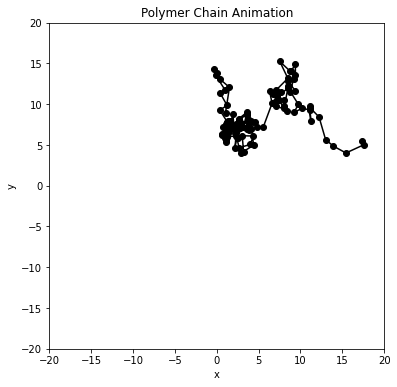

In [24]:
import matplotlib.animation as animation
def animate_chain(ticks, positionsX, positionsY, world):
    """
    Animate the motion of the polymer chain over a number of time steps.
    - ticks: Number of time steps.
    - positionsX, positionsY: Initial positions of residues.
    - world: Boundary for movement.
    """
    positionsX_array = np.zeros((N, ticks))
    positionsY_array = np.zeros((N, ticks))

    # Initialize positions
    positionsX_array[:, 0] = positionsX
    positionsY_array[:, 0] = positionsY

    for t in range(1, ticks):
        for _ in range(N):  # Attempt to move N residues per tick
            random_index = np.random.randint(0, N)
            positionsX, positionsY = move_residue(random_index, positionsX, positionsY, world)

        # Store positions for this time step
        positionsX_array[:, t] = positionsX
        positionsY_array[:, t] = positionsY

    return positionsX_array, positionsY_array


# Simulate and visualize animation for 50 ticks
ticks = 50
positionsX_array, positionsY_array = animate_chain(ticks, positionsX, positionsY, world)

# Use the animation function provided in plotting_package
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots(figsize=(6, 6))
ax.set(xlabel='x', ylabel='y', xlim=[-world, world], ylim=[-world, world])
line, = ax.plot([], [], '-o', color='k')


def update(frame):
    line.set_data(positionsX_array[:, frame], positionsY_array[:, frame])
    return line,


ani = FuncAnimation(fig, update, frames=ticks, interval=100, blit=True)
plt.title("Polymer Chain Animation")
save_path =  "polymer_chain_animation.gif"
writer = PillowWriter(fps=10)  # For GIF, you can use PillowWriter. For MP4, use 'ffmpeg'
ani.save(save_path, writer=writer)
plt.show()


In [25]:
#2

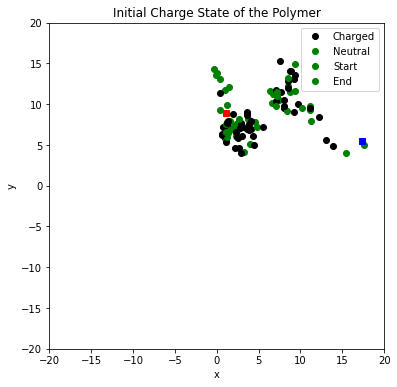

In [26]:
# Adding charge properties to residues

# Variables for charge calculation
pH = 7  # pH of the environment
pKa = 7  # pKa of the residues

# Calculate the probability of a residue being charged
def calculate_charge_probability(pH, pKa):
    Ka = 10**-pKa  # Dissociation constant
    H_concentration = 10**-pH
    return Ka / (Ka + H_concentration)

charge_probability = calculate_charge_probability(pH, pKa)

# Initialize charges for residues
charges = np.zeros(N)
for i in range(N):
    charges[i] = -1 if np.random.rand() < charge_probability else 0

# Plot the initial charge state of the polymer
fig, ax = plt.subplots(figsize=(6, 6))
ax.set(xlabel='x', ylabel='y', xlim=[-world, world], ylim=[-world, world])
for i in range(N):
    if charges[i] == -1:
        ax.plot(positionsX[i], positionsY[i], 'go')  # Charged residue
    else:
        ax.plot(positionsX[i], positionsY[i], 'ko')  # Neutral residue
ax.plot(positionsX[0], positionsY[0], 'rs', label='Start')
ax.plot(positionsX[-1], positionsY[-1], 'bs', label='End')
plt.title("Initial Charge State of the Polymer")
plt.legend(['Charged', 'Neutral', 'Start', 'End'])
plt.show()


In [27]:
#2d

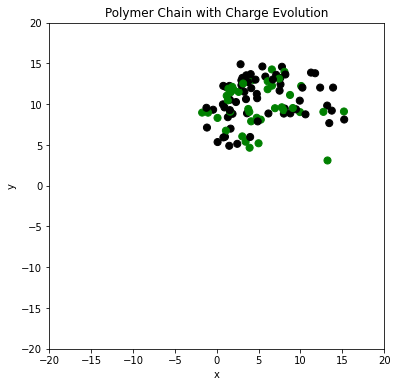

In [28]:
def update_charges(charges, pH, pKa):
    """
    Update the charge states of residues based on pH and pKa.
    - charges: Current charge array.
    - pH: Current pH of the environment.
    - pKa: pKa of residues.
    """
    charge_prob = calculate_charge_probability(pH, pKa)
    for i in range(len(charges)):
        charges[i] = -1 if np.random.rand() < charge_prob else 0
    return charges


def animate_chain_with_charges(ticks, positionsX, positionsY, charges, world, pH, pKa):
    """
    Animate the motion of the polymer chain over a number of time steps with charge updates.
    - ticks: Number of time steps.
    - positionsX, positionsY: Initial positions of residues.
    - charges: Initial charge states of residues.
    - world: Boundary for movement.
    - pH, pKa: Environment pH and residue pKa.
    """
    positionsX_array = np.zeros((N, ticks))
    positionsY_array = np.zeros((N, ticks))
    charges_array = np.zeros((N, ticks))

    # Initialize positions and charges
    positionsX_array[:, 0] = positionsX
    positionsY_array[:, 0] = positionsY
    charges_array[:, 0] = charges

    for t in range(1, ticks):
        for _ in range(N):  # Attempt to move N residues per tick
            random_index = np.random.randint(0, N)
            positionsX, positionsY = move_residue(random_index, positionsX, positionsY, world)

        # Update charges
        charges = update_charges(charges, pH, pKa)

        # Store positions and charges for this time step
        positionsX_array[:, t] = positionsX
        positionsY_array[:, t] = positionsY
        charges_array[:, t] = charges

    return positionsX_array, positionsY_array, charges_array


# Simulate for 50 ticks
positionsX_array, positionsY_array, charges_array = animate_chain_with_charges(
    ticks, positionsX, positionsY, charges, world, pH, pKa
)

# Visualize charge evolution
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(figsize=(6, 6))
ax.set(xlabel='x', ylabel='y', xlim=[-world, world], ylim=[-world, world])
scat = ax.scatter([], [], c=[], cmap=ListedColormap(['black', 'green']), s=50)


def update_with_charges(frame):
    scat.set_offsets(np.c_[positionsX_array[:, frame], positionsY_array[:, frame]])
    scat.set_array(charges_array[:, frame])
    return scat,


ani = FuncAnimation(fig, update_with_charges, frames=ticks, interval=100, blit=True)
save_path = "polymer_chain_charge_animation.gif"
writer = PillowWriter(fps=10)  # For GIF, you can use PillowWriter. For MP4, use 'ffmpeg'
plt.title("Polymer Chain with Charge Evolution")
ani.save(save_path, writer=writer)
plt.show()


In [29]:
#3

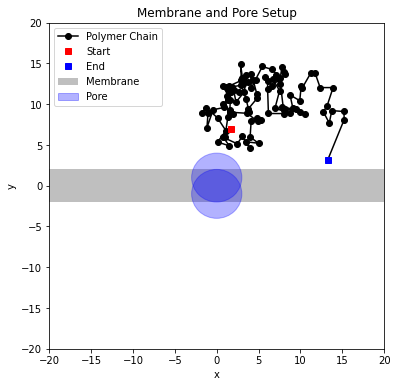

In [30]:
# Variables for membrane and pore
membrane_thickness = 2  # Thickness of the membrane
pore_radius = 3  # Radius of the pore

# Visualization of the membrane and pore
fig, ax = plt.subplots(figsize=(6, 6))
ax.set(xlabel='x', ylabel='y', xlim=[-world, world], ylim=[-world, world])

# Membrane representation
ax.axhspan(0, membrane_thickness, facecolor='gray', alpha=0.5, label='Membrane')
ax.axhspan(-membrane_thickness, 0, facecolor='gray', alpha=0.5)

# Pore representation
circle_top = plt.Circle((0, membrane_thickness / 2), pore_radius, color='blue', alpha=0.3, label='Pore')
circle_bottom = plt.Circle((0, -membrane_thickness / 2), pore_radius, color='blue', alpha=0.3)
ax.add_patch(circle_top)
ax.add_patch(circle_bottom)

# Polymer chain overlay
ax.plot(positionsX, positionsY, '-o', color='k', label='Polymer Chain')
ax.plot(positionsX[0], positionsY[0], 'rs', label='Start')
ax.plot(positionsX[-1], positionsY[-1], 'bs', label='End')

plt.title("Membrane and Pore Setup")
plt.legend()
plt.show()


In [31]:
#3c

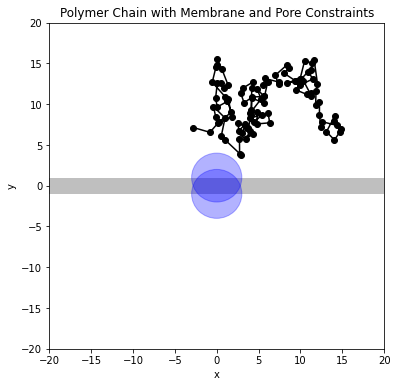

In [32]:
def is_within_pore(x, y, pore_radius, membrane_thickness):
    """
    Determine if a point (x, y) is within the pore or membrane region.
    - x, y: Coordinates of the residue.
    - pore_radius: Radius of the pore.
    - membrane_thickness: Thickness of the membrane.
    Returns:
        True if within the pore, False if in the membrane.
    """
    if -pore_radius <= x <= pore_radius and -membrane_thickness / 2 <= y <= membrane_thickness / 2:
        return True  # Inside the pore
    elif -membrane_thickness / 2 <= y <= membrane_thickness / 2:
        return False  # Inside the membrane
    return True  # Outside the membrane


def move_residue_with_membrane(i, positionsX, positionsY, world, pore_radius, membrane_thickness):
    """
    Move a single residue with membrane and pore constraints.
    """
    original_x, original_y = positionsX[i], positionsY[i]

    positionsX, positionsY = move_residue(i, positionsX, positionsY, world)
    new_x, new_y = positionsX[i], positionsY[i]

    if not is_within_pore(new_x, new_y, pore_radius, membrane_thickness):
        # Revert move if it's within the membrane
        positionsX[i], positionsY[i] = original_x, original_y

    return positionsX, positionsY


def simulate_with_membrane(ticks, positionsX, positionsY, charges, world, pore_radius, membrane_thickness):
    """
    Simulate the polymer chain with membrane and pore constraints.
    """
    positionsX_array = np.zeros((N, ticks))
    positionsY_array = np.zeros((N, ticks))

    # Initialize positions
    positionsX_array[:, 0] = positionsX
    positionsY_array[:, 0] = positionsY

    for t in range(1, ticks):
        for _ in range(N):  # Attempt to move N residues per tick
            random_index = np.random.randint(0, N)
            positionsX, positionsY = move_residue_with_membrane(
                random_index, positionsX, positionsY, world, pore_radius, membrane_thickness
            )

        # Store positions for this time step
        positionsX_array[:, t] = positionsX
        positionsY_array[:, t] = positionsY

    return positionsX_array, positionsY_array


# Simulate and visualize motion with the membrane
ticks = 50
positionsX_array, positionsY_array = simulate_with_membrane(
    ticks, positionsX, positionsY, charges, world, pore_radius, membrane_thickness
)

# Animate the result
fig, ax = plt.subplots(figsize=(6, 6))
ax.set(xlabel='x', ylabel='y', xlim=[-world, world], ylim=[-world, world])
line, = ax.plot([], [], '-o', color='k')
membrane_patch = ax.axhspan(-membrane_thickness / 2, membrane_thickness / 2, facecolor='gray', alpha=0.5)
pore_circle_top = plt.Circle((0, membrane_thickness / 2), pore_radius, color='blue', alpha=0.3)
pore_circle_bottom = plt.Circle((0, -membrane_thickness / 2), pore_radius, color='blue', alpha=0.3)
ax.add_patch(pore_circle_top)
ax.add_patch(pore_circle_bottom)


def update_membrane(frame):
    line.set_data(positionsX_array[:, frame], positionsY_array[:, frame])
    return line,


ani = FuncAnimation(fig, update_membrane, frames=ticks, interval=100, blit=True)
save_path = "polymer_chain_membrane_animation.gif"
writer = PillowWriter(fps=10)  # For GIF, you can use PillowWriter. For MP4, use 'ffmpeg'
plt.title("Polymer Chain with Membrane and Pore Constraints")
ani.save(save_path, writer=writer)
plt.show()


In [33]:
#3d

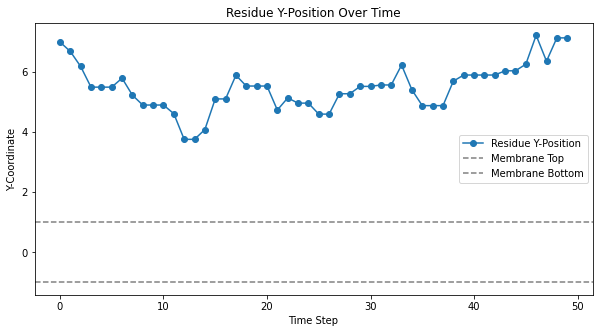

0

In [34]:
def track_y_position(ticks, positionsY_array, membrane_thickness):
    """
    Track the y-coordinate of the first residue over time and count compartment changes.
    - ticks: Number of time steps.
    - positionsY_array: Array of y-coordinates over time.
    - membrane_thickness: Thickness of the membrane.
    Returns:
        y_positions: List of y-coordinates over time for the first residue.
        compartment_changes: Number of times the residue changes compartments.
    """
    y_positions = positionsY_array[0, :]  # Track the first residue
    compartment_changes = 0

    # Determine compartments: Endosome (y > 0) or Cytosol (y < 0)
    current_compartment = "endosome" if y_positions[0] > 0 else "cytosol"
    for y in y_positions:
        new_compartment = "endosome" if y > membrane_thickness / 2 else "cytosol" if y < -membrane_thickness / 2 else "membrane"
        if new_compartment != current_compartment and new_compartment != "membrane":
            compartment_changes += 1
            current_compartment = new_compartment

    return y_positions, compartment_changes


# Analyze the trajectory
y_positions, compartment_changes = track_y_position(ticks, positionsY_array, membrane_thickness)

# Plot the trajectory
time_steps = np.arange(ticks)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(time_steps, y_positions, '-o', label='Residue Y-Position')
ax.axhline(membrane_thickness / 2, color='gray', linestyle='--', label='Membrane Top')
ax.axhline(-membrane_thickness / 2, color='gray', linestyle='--', label='Membrane Bottom')
ax.set(xlabel='Time Step', ylabel='Y-Coordinate', title='Residue Y-Position Over Time')
ax.legend()
plt.show()

# Output the number of compartment changes
compartment_changes

In [35]:
#3e

In [36]:
import numpy as np

# Function to calculate the probability of a charged residue entering the pore
def move_with_energy_barrier(i, positionsX, positionsY, charges, world, pore_radius, membrane_thickness):
    x, y = positionsX[i], positionsY[i]

    # Determine if the residue is attempting to enter the pore
    inside_pore = (x**2 + y**2) < pore_radius**2 and abs(y) < membrane_thickness / 2

    # Energy barrier for charged residues
    if inside_pore and charges[i] == -1:
        delta_e_kT = 1  # ΔE/(kT) for entering the pore
        probability = np.exp(-delta_e_kT)
        if np.random.rand() > probability:
            # Reject the move
            return positionsX, positionsY

    # Proceed with normal move logic if move is allowed
    positionsX[i] = np.clip(x + np.random.uniform(-1, 1), -world, world)
    positionsY[i] = np.clip(y + np.random.uniform(-1, 1), -world, world)

    return positionsX, positionsY

In [37]:
#3f

In [38]:
# Function to update charges based on local pH and pKa
def update_charges(positionsY, pH_endosome, pH_cytosol, pKa, world):
    charges = []
    for y in positionsY:
        # Determine which compartment the residue is in
        pH = pH_endosome if y > 0 else pH_cytosol

        # Calculate probability of being charged
        proton_concentration = 10 ** (-pH)
        ka = 10 ** (-pKa)
        probability_charged = ka / (ka + proton_concentration)

        # Assign charge based on probability
        charge = -1 if np.random.rand() < probability_charged else 0
        charges.append(charge)
    return charges

# Example usage
world_size = 10
residues = 20
positionsX = np.random.uniform(-world_size, world_size, residues)
positionsY = np.random.uniform(-world_size, world_size, residues)
pH_endosome = 5
pH_cytosol = 7
pKa = 7

charges = update_charges(positionsY, pH_endosome, pH_cytosol, pKa, world_size)
print("Updated charges:", charges)

Updated charges: [0, -1, 0, 0, 0, -1, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0]


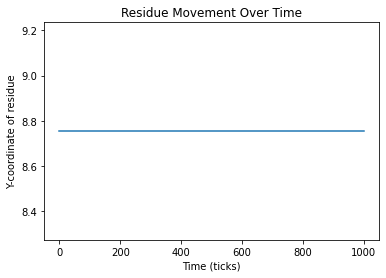

In [39]:
# Parameters
world_size = 10
ticks = 1000
pore_radius = 3
membrane_thickness = 2
residues = 20
positionsX = np.random.uniform(-world_size, world_size, residues)
positionsY = np.random.uniform(-world_size, world_size, residues)
pH_endosome = 5
pH_cytosol = 7
pKa = 7

# Simulation loop
for t in range(ticks):
    for i in range(residues):
        positionsX, positionsY = move_with_energy_barrier(i, positionsX, positionsY, charges, world_size, pore_radius, membrane_thickness)
    charges = update_charges(positionsY, pH_endosome, pH_cytosol, pKa, world_size)

# Plotting y-coordinate of a residue vs. time
import matplotlib.pyplot as plt

residue_index = 0  # Example residue to track
y_trajectory = [positionsY[residue_index]]

for t in range(ticks):
    y_trajectory.append(positionsY[residue_index])

plt.plot(range(ticks + 1), y_trajectory)
plt.xlabel("Time (ticks)")
plt.ylabel("Y-coordinate of residue")
plt.title("Residue Movement Over Time")
plt.show()